# RICE LEAF DISEASE DETECTION

## INTRODUCTION
The rice leaf suffers from several bacterial, viral, or fungal diseases and these diseases reduce rice production significantly. To sustain rice demand for a vast population globally.The rice leaves related diseases often pose threats to the sustainable production of rice affecting many farmers around the world. Early diagnosis and appropriate remedy of the rice leaf infection is crucial in facilitating healthy growth of the rice plants to ensure adequate supply and food security to the rapidly increasing population.
### RICE LEAF DISEASE:
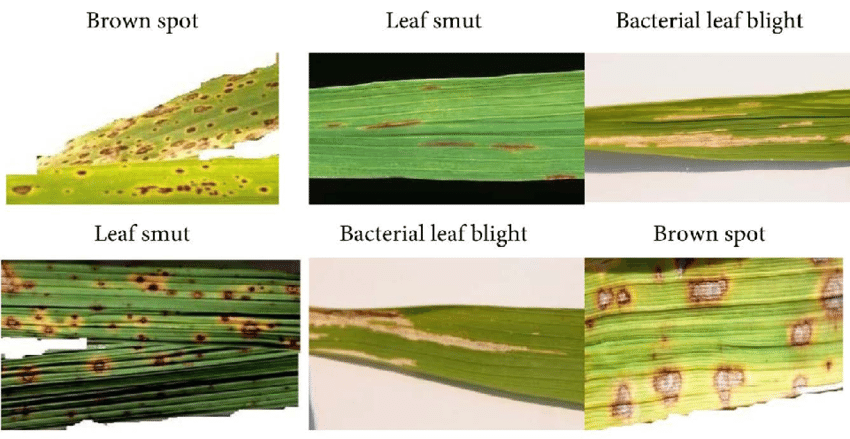

### WE HAVE DEVICE THE PROJECT INTO MULTIPLE STEPS
* Importing library
* Loading data
* Preparing data
* Data Processing 
* Model building
* Training
* Evaluation
* Testing

### DATA SUMMARY
This dataset contains 120 jpg images of disease infected rice leaves. The images are grouped into 3 classes based on the type of disease. There are 40 images in each class.

Classes

* Leaf smut
* Brown spot
* Bacterial leaf blight

## PYTHON IMPLIMENTATION

### IMPORTING NECESSARY LIBRARY

In [11]:
%pip install split-folders

Note: you may need to restart the kernel to use updated packages.


In [12]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Activation, Dense, Conv2D, Flatten 
from tensorflow.keras import models, layers
model = models.Sequential()
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array
import matplotlib.pyplot as plt
%matplotlib inline
import random
import cv2
import os
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

### MAKE SUBSET OF TRAIN, TEST, VALIDATION

In [13]:
import splitfolders
splitfolders.ratio(r"C:\Users\arbaj\Projects\RiceLeaf Disease Detection\Data", output="output", seed=1337, ratio=(.8, 0.1,0.1))

Copying files: 119 files [00:00, 136.76 files/s]


In [14]:
# Sorting the path of data into veriable
train_dir = r'C:\Users\arbaj\Python\Projects\RIce leaf\output\train'  #Location of training images
validation_dir = r'C:\Users\arbaj\Projects\RiceLeaf Disease Detection\output\train' # Location of test images
test_dir = r'C:\Users\arbaj\Projects\RiceLeaf Disease Detection\output\val' # Location of test images

### GENERATING TRAINING AND VALIDATION BATCHES OF IMAGES

In [ ]:
# Generating batches of image data
train_datagen = ImageDataGenerator(
    rescale= (1./255),
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True)

val_datagen = ImageDataGenerator(rescale=(1./255))

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(180,180),
    batch_size=16,
    color_mode='rgb',
    class_mode='categorical')

val_generator = val_datagen.flow_from_directory(
    validation_dir,
    target_size=(180,180),
    batch_size=16,
    color_mode='rgb',
    class_mode='categorical')

### PLOTTING TRAIN IMAGES WITH THEIR LABELS

In [ ]:
# plotting train images with their labels
def plots(ims, figsize=(20,25), rows=4, interp = False, title = None):
    f = plt.figure(figsize=figsize)
    cols = len(ims) // rows if len(ims) % 2 ==0 else len(ims) // rows+1
    for i in range(len(ims)):
        sp = f.add_subplot(rows, cols, i+1)
        sp.axis('off')
        sp.set_title(class_names[title[i].tolist().index(1)],fontsize=16)
        plt.imshow(ims[i])


# Make list of classes
class_names = ['Bacterial leaf blight', 'Brown spot', 'Leaf smut']

In [ ]:
imgs, labels = next(train_generator)
plots(imgs, title = labels)

## CNN MODEL ARCHITECTURE

In [ ]:
from tensorflow.keras import models, layers

model = models.Sequential()
model.add(layers.Conv2D(filters=32, kernel_size=(3,3), activation='relu', input_shape=(180,180,3)))
model.add(layers.MaxPool2D(pool_size=(2,2)))
model.add(layers.Conv2D(filters=64, kernel_size=(3,3), activation='relu'))
model.add(layers.MaxPool2D(pool_size=(2,2)))
model.add(layers.Conv2D(filters=128, kernel_size=(3,3), activation='relu'))
model.add(layers.MaxPool2D(pool_size=(2,2)))
model.add(layers.Conv2D(filters=256, kernel_size=(3,3), activation='relu'))
model.add(layers.MaxPool2D(pool_size=(2,2)))
model.add(layers.Dropout(rate=0.5))
model.add(layers.Flatten())
model.add(layers.Dense(3, activation='softmax'))